# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [237]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

In [238]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


import os
print("Current Working Directory:", os.getcwd())

print("Local Folder Contents:", os.listdir("."))

Current Working Directory: c:\Users\eye24\OneDrive\ドキュメント\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3
Local Folder Contents: ['Ai-Nakayama_data', 'Ai-Nakayama_hw_3.ipynb']


In [239]:
import pandas as pd
df_PCPS = pd.read_csv("../../hw\hw_3\Ai-Nakayama_data\dataset_2026-05-28T05_05_49.952901377Z_DEFAULT_INTEGRATION_IMF.RES_WEO_9.0.0.csv")
df_PCPS.head()



,COUNTRY,INDICATOR,FREQUENCY,TIME_PERIOD,OBS_VALUE,SCALE
0,World,"All commodities, Commodity price index",Annual,1997,56.123,Units
1,World,"All commodities, Commodity price index",Annual,1998,47.306,Units
2,World,"All commodities, Commodity price index",Annual,1999,47.983,Units
3,World,"All commodities, Commodity price index",Annual,2000,60.391,Units
4,World,"All commodities, Commodity price index",Annual,2001,56.192,Units


In [240]:
import pandas as pd

path = "../../hw/hw_3/Ai-Nakayama_data/Global_Policy_Uncertainty_Data.csv"
df_GEPU = pd.read_csv(path, encoding='cp932')

df_GEPU.head()

,Year,Month,GEPU_current,GEPU_ppp
0,1997,1,76.059427,79.856772
1,1997,2,76.286023,75.828220
2,1997,3,66.810541,64.850547
3,1997,4,71.716551,71.855863
4,1997,5,75.229731,82.058365


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*
---
Economic Policy Uncertainty Index #https://www.policyuncertainty.com/global_monthly.html
IMF Primary Commodity Price System (PCPS) #https://data.imf.org/en/Data-Explorer?datasetUrn=IMF.RES:WEO(9.0.0)&INDICATOR=PALLFNFW

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [241]:
# 1. Inspect data structure using pandas methods
df_PCPS.info()
df_PCPS.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   COUNTRY      30 non-null     object 
 1   INDICATOR    30 non-null     object 
 2   FREQUENCY    30 non-null     object 
 3   TIME_PERIOD  30 non-null     int64  
 4   OBS_VALUE    30 non-null     float64
 5   SCALE        30 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.5+ KB


,COUNTRY,INDICATOR,FREQUENCY,TIME_PERIOD,OBS_VALUE,SCALE
0,World,"All commodities, Commodity price index",Annual,1997,56.123,Units
1,World,"All commodities, Commodity price index",Annual,1998,47.306,Units
2,World,"All commodities, Commodity price index",Annual,1999,47.983,Units
3,World,"All commodities, Commodity price index",Annual,2000,60.391,Units
4,World,"All commodities, Commodity price index",Annual,2001,56.192,Units


In [242]:
# 2. Rename columns and select a clean subset
df_PCPS_renamed = df_PCPS.rename(columns={
    'TIME_PERIOD' : 'Year',
    'OBS_VALUE' : 'Comodity Price Index'
})
df_PCPS_renamed.head()

,COUNTRY,INDICATOR,FREQUENCY,Year,Comodity Price Index,SCALE
0,World,"All commodities, Commodity price index",Annual,1997,56.123,Units
1,World,"All commodities, Commodity price index",Annual,1998,47.306,Units
2,World,"All commodities, Commodity price index",Annual,1999,47.983,Units
3,World,"All commodities, Commodity price index",Annual,2000,60.391,Units
4,World,"All commodities, Commodity price index",Annual,2001,56.192,Units


In [243]:
# 3. Filter row or column filters if necessary
df_PCPS_filtered = df_PCPS_renamed[['Year', 'Comodity Price Index']]
df_PCPS_filtered.head()

,Year,Comodity Price Index
0,1997,56.123
1,1998,47.306
2,1999,47.983
3,2000,60.391
4,2001,56.192


In [244]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [245]:
# 1. Load and clean the secondary dataset
df_GEPU.info()
df_GEPU.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          347 non-null    int64  
 1   Month         347 non-null    int64  
 2   GEPU_current  347 non-null    float64
 3   GEPU_ppp      347 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 11.0 KB


,Year,Month,GEPU_current,GEPU_ppp
0,1997,1,76.059427,79.856772
1,1997,2,76.286023,75.828220
2,1997,3,66.810541,64.850547
3,1997,4,71.716551,71.855863
4,1997,5,75.229731,82.058365


In [246]:
df_GEPU_renamed = df_GEPU.rename(columns={
    'GEPU_current' : 'GEPU'})
df_GEPU_renamed.head()

,Year,Month,GEPU,GEPU_ppp
0,1997,1,76.059427,79.856772
1,1997,2,76.286023,75.828220
2,1997,3,66.810541,64.850547
3,1997,4,71.716551,71.855863
4,1997,5,75.229731,82.058365


In [247]:
df_GEPU_filtered = df_GEPU_renamed[['Year', 'Month', 'GEPU']]
df_GEPU_filtered.head()

,Year,Month,GEPU
0,1997,1,76.059427
1,1997,2,76.286023
2,1997,3,66.810541
3,1997,4,71.716551
4,1997,5,75.229731


In [248]:
# 2. Merge your datasets on a common key
df_GEPU_filtered = df_GEPU_filtered.dropna(subset=['Year'])

df_PCPS_filtered['Year'] = df_PCPS_filtered['Year'].astype('int64')
df_GEPU_filtered['Year'] = df_GEPU_filtered['Year'].astype('int64')

df_merged = pd.merge(df_PCPS_filtered, df_GEPU_filtered, on='Year', how='inner')
print(df_merged)

     Year  Comodity Price Index  Month        GEPU
0    1997                56.123      1   76.059427
1    1997                56.123      2   76.286023
2    1997                56.123      3   66.810541
3    1997                56.123      4   71.716551
4    1997                56.123      5   75.229731
..    ...                   ...    ...         ...
342  2025               166.946      7  406.887570
343  2025               166.946      8  343.339060
344  2025               166.946      9  308.478231
345  2025               166.946     10  404.873052
346  2025               166.946     11  371.095352

[347 rows x 4 columns]


C:\Users\eye24\AppData\Local\Temp\ipykernel_21616\1842018346.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_PCPS_filtered['Year'] = df_PCPS_filtered['Year'].astype('int64')


In [249]:
df_merged.head()

,Year,Comodity Price Index,Month,GEPU
0,1997,56.123,1,76.059427
1,1997,56.123,2,76.286023
2,1997,56.123,3,66.810541
3,1997,56.123,4,71.716551
4,1997,56.123,5,75.229731


In [250]:
df_merged.tail()

,Year,Comodity Price Index,Month,GEPU
342,2025,166.946,7,406.887570
343,2025,166.946,8,343.339060
344,2025,166.946,9,308.478231
345,2025,166.946,10,404.873052
346,2025,166.946,11,371.095352


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*
---
Merged year information of two data sets. 
Used inner function so that the data wxisting on both datasets apperas on the merged one. 
The same number of rows as the left data (GEPU) was kept.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [251]:
# Apply groupby aggregation or implement one of the backup grouping strategies

df_merged['Uncertainty_Group'] = df_merged['GEPU'].apply(
    lambda x: 'High_Uncertainty' if x > 100 else 'Low_Uncertainty'
)

result = df_merged.groupby('Uncertainty_Group')['Comodity Price Index'].agg(['mean', 'median', 'min', 'max'])


- *Extra Credit: Write your economic or policy related interpretation here*
---
The Commodity Price Index is strongly affected by economic uncertainty. The mean is 1.5 times higher, and the median is 2 times higher, as uncertainty in the economy increases. This shift might be attributed to the heightened economic uncertainty, which drives investors to invest in commodities, which are visible products, and secure their assets for the short term. The other possible reason is that economic policy raises the price of the commodity. For example, political intervention in the market, due to the country's economic uncertainty, affects the commodity market by reorganizing and adjusting existing supply chains, thereby increasing the price index. 

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

In [252]:
df_agg = (
    df_merged.groupby("Uncertainty_Group")["Comodity Price Index"]
    .mean()
    .reset_index()
)

Text(0, 0.5, 'Mean Commodity Price Index')

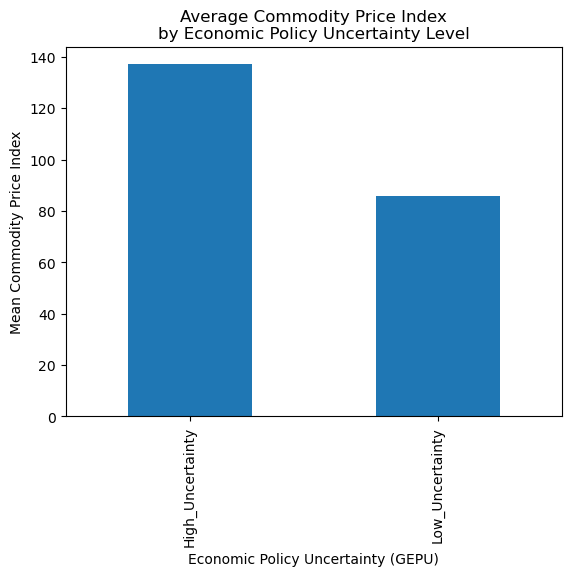

In [253]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups

import matplotlib.pyplot as plt
df_plot = df_agg.set_index("Uncertainty_Group")["Comodity Price Index"]
df_plot.plot(kind="bar")

plt.title("Average Commodity Price Index\nby Economic Policy Uncertainty Level")
plt.xlabel("Economic Policy Uncertainty (GEPU)")
plt.ylabel("Mean Commodity Price Index")

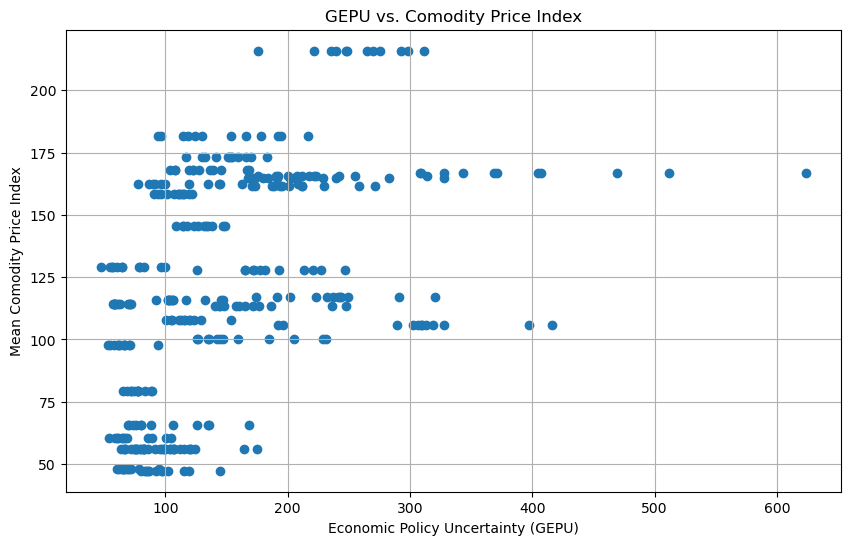

In [254]:
# Plot 2: Customized scatter plot of primary policy variables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
x = df_merged["GEPU"],
y = df_merged["Comodity Price Index"]
)

plt.xlabel("Economic Policy Uncertainty (GEPU)")
plt.ylabel("Mean Comodity Price Index")
plt.title('GEPU vs. Comodity Price Index')
plt.grid(True)
plt.show()

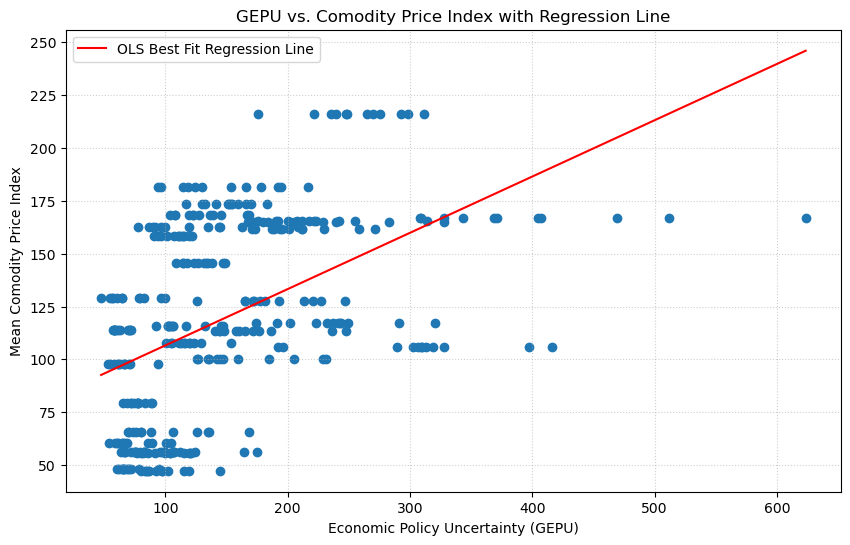

In [255]:
# Fit a simple linear regression and overlay the line of best fit
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import pandas as pd


plt.figure(figsize=(10, 6))
plt.scatter(
x = df_merged["GEPU"],
y = df_merged["Comodity Price Index"]
)

plt.xlabel("Economic Policy Uncertainty (GEPU)")
plt.ylabel("Mean Comodity Price Index")
plt.title('GEPU vs. Comodity Price Index')
plt.grid(True)

Y = df_merged["Comodity Price Index"]
X = df_merged["GEPU"]
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const)
results = model.fit()

plt.plot(
    X_plot,
    Y_plot_pred,
    color= 'red',
    label='OLS Best Fit Regression Line')

plt.xlabel("Economic Policy Uncertainty (GEPU)")
plt.ylabel("Mean Comodity Price Index")
plt.title("GEPU vs. Comodity Price Index with Regression Line")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*
---
Plot 1's bar charts show that High Uncertainty (GEPU>100) has a higher Commodity Price Index than the period of Low Uncertainty (GEPU<100). It demonstrates that the commodity market is sensitive to global economic uncertainty.

Plot 2, with the regression line, shows a positive slope, even though there is natural variance in the data. It provides visual evidence that as the Global Economic Policy Uncertainty index climbs, the Commodity Price Index systematically rises.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.